# 08 · Operational analysis on the competition footage

The test-set metrics (notebook 07) are excellent **in the dataset domain**. This
notebook measures how the model actually behaves on the **3 TEKNOFEST night/
surveillance clips** — and documents the honest limitations seen in the live demo:

1. Behavior detection is **event-based**: it fires at specific moments (when the
   driver + action are visible), **not continuously** across the whole clip.
2. The delivered model has a **`cigarette` class**, so it *can* flag smoking on
   tekno-01 — but that class was learned only from this clip, so treat it as a
   per-clip demo, not general smoking detection (see leakage note, nb 07).
3. **License-plate OCR varies frame to frame** and is approximate (464p source).

In [1]:
%matplotlib inline
import cv2, glob, numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
DEV = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
veh = YOLO("../backend/yolov8x.pt")
beh = YOLO("../backend/runs/behavior_combined/weights/best.pt")

def behavior_per_frame(video, step=5):
    cap = cv2.VideoCapture(video); labels=[]; idx=0
    while True:
        ok, fr = cap.read()
        if not ok: break
        if idx % step == 0:
            r = veh.predict(fr, imgsz=512, conf=0.25, classes=[2,3,5,7], device=DEV, verbose=False)[0]
            lab="no vehicle"
            if len(r.boxes):
                b=max(r.boxes,key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
                x1,y1,x2,y2=[int(v) for v in b.xyxy[0].tolist()]
                crop=cv2.resize(fr[max(0,y1):y2,max(0,x1):x2],None,fx=3,fy=3)
                rr=beh.predict(crop,imgsz=512,conf=0.20,device=DEV,verbose=False)[0]
                lab = beh.names[int(max(rr.boxes,key=lambda b:float(b.conf)).cls)] if len(rr.boxes) else "none"
            labels.append(lab)
        idx+=1
    cap.release(); return labels

clips={v.split('/')[-1].split(chr(92))[-1].replace('.mp4',''): behavior_per_frame(v)
       for v in sorted(glob.glob("../frontend/public/demo-videos/*.mp4"))}
print({k:len(v) for k,v in clips.items()}, "sampled frames per clip (~5 FPS)")

{'tekno-01': 85, 'tekno-02': 92, 'tekno-03': 77} sampled frames per clip (~5 FPS)


### Timeline — *when* each behavior is detected (event-based, not continuous)

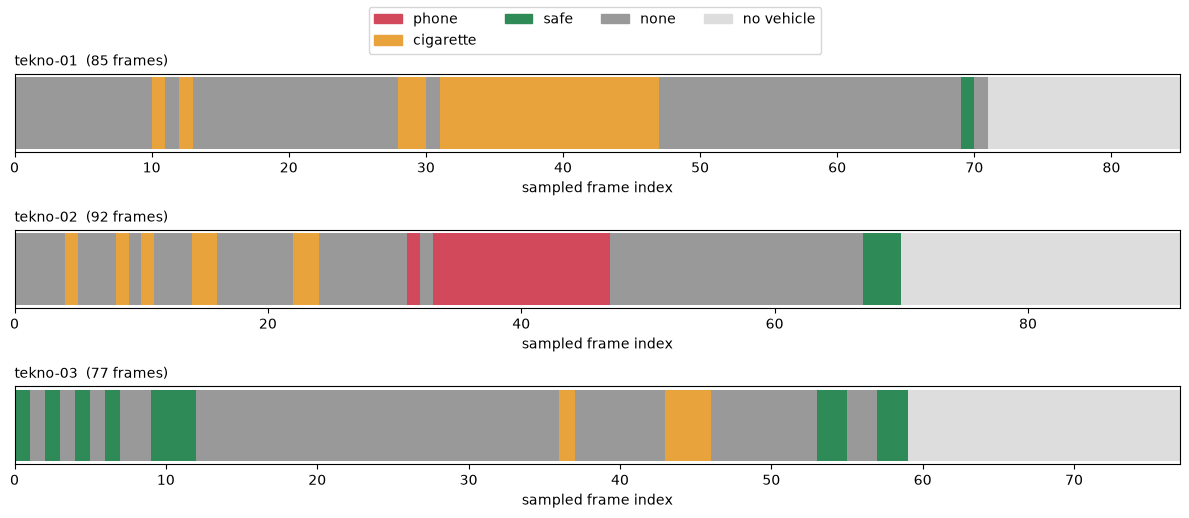

In [2]:
cmap={"phone":"#d1495b","cigarette":"#e8a33d","safe":"#2e8b57","none":"#999999","no vehicle":"#dddddd"}
fig,axes=plt.subplots(len(clips),1,figsize=(12,1.4*len(clips)+1),squeeze=False)
for ax,(name,labs) in zip(axes[:,0],clips.items()):
    for i,l in enumerate(labs):
        ax.barh(0,1,left=i,color=cmap.get(l,"#000"),edgecolor="none")
    ax.set_yticks([]); ax.set_xlim(0,len(labs)); ax.set_title(f"{name}  ({len(labs)} frames)",loc="left",fontsize=10)
    ax.set_xlabel("sampled frame index")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=c,label=l) for l,c in cmap.items()],ncol=4,loc="upper center")
plt.tight_layout(rect=[0,0,1,0.93]); plt.show()

### Detection rate per clip

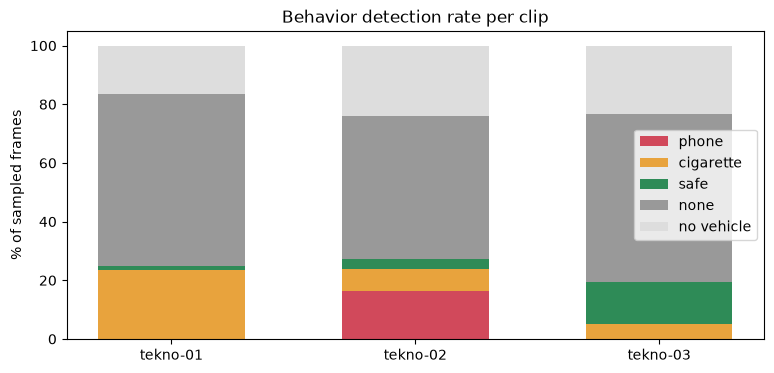

tekno-01: phone 0% | cigarette 24% | safe 1% | none 59%
tekno-02: phone 16% | cigarette 8% | safe 3% | none 49%
tekno-03: phone 0% | cigarette 5% | safe 14% | none 57%


In [3]:
import numpy as np
fig,ax=plt.subplots(figsize=(9,4)); names=list(clips); w=0.6; bottom=np.zeros(len(names))
for lab,c in [("phone","#d1495b"),("cigarette","#e8a33d"),("safe","#2e8b57"),("none","#999999"),("no vehicle","#dddddd")]:
    vals=[100*clips[n].count(lab)/max(len(clips[n]),1) for n in names]
    ax.bar(names,vals,w,bottom=bottom,label=lab,color=c); bottom+=vals
ax.set_ylabel("% of sampled frames"); ax.set_title("Behavior detection rate per clip"); ax.legend(); plt.show()
for n in names:
    L=clips[n]; d=lambda k:100*L.count(k)/max(len(L),1)
    print(f"{n}: phone {d('phone'):.0f}% | cigarette {d('cigarette'):.0f}% | safe {d('safe'):.0f}% | none {d('none'):.0f}%")

### License-plate OCR across frames (consistency check)

In [4]:
import re, easyocr
reader=easyocr.Reader(["en"],gpu=(DEV!="cpu"),verbose=False)
PLATE=re.compile(r"(\d{2})([A-Z]{1,3})(\d{2,4})")
def plate_reads(video, n=10, step=12):
    cap=cv2.VideoCapture(video); out=[]; idx=0; got=0
    while got<n:
        ok,fr=cap.read()
        if not ok: break
        if idx%step==0:
            r=veh.predict(fr,imgsz=512,conf=0.25,classes=[2,3,5,7],device=DEV,verbose=False)[0]
            if len(r.boxes):
                b=max(r.boxes,key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
                x1,y1,x2,y2=[int(v) for v in b.xyxy[0].tolist()]; ph=y2-y1; pw=x2-x1
                roi=cv2.resize(fr[y1+int(ph*.6):y2,x1+int(pw*.15):x1+int(pw*.85)],None,fx=5,fy=5)
                toks=reader.readtext(roi,allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789",detail=0)
                comp="".join(re.sub(r"[^A-Z0-9]","",t.upper()) for t in toks)
                m=PLATE.search(comp); out.append(f"{m.group(1)} {m.group(2)} {m.group(3)}" if m else (comp or "-")); got+=1
        idx+=1
    cap.release(); return out
v0=sorted(glob.glob("../frontend/public/demo-videos/*.mp4"))[0]
reads=plate_reads(v0)
print("plate reads across frames (tekno-01, true plate = '34 TC 8532'):")
for r in reads: print("  ", r)

plate reads across frames (tekno-01, true plate = '34 TC 8532'):
   148572
   1452
   085
   M
   I4852
   I0052
   04652
   044052
   I00522
   0700522


### Best-evidence snapshot (the strategy used in the backend)

Because detection is intermittent, the backend does **not** rely on a single live
frame: per session it keeps the **closest notable frame** (largest vehicle area on a
frame where a risk behavior / QoD fired) and saves *that* as the incident photo —
served at `GET /api/incidents/{id}/snapshot` and shown in the app's *Incidentes*
screen. Below we reproduce that selection on each clip.

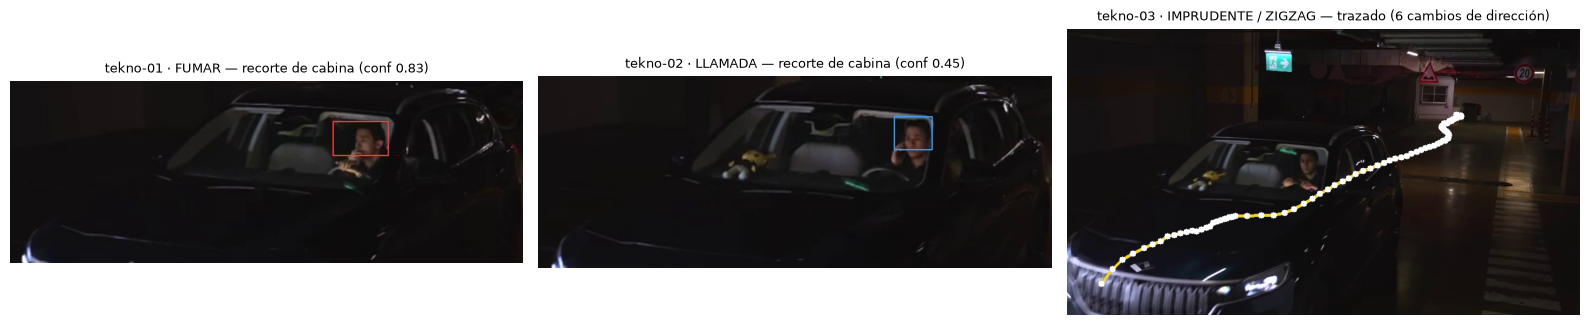

Each clip maps to ONE risk case. tekno-03's risk is the trajectory (zigzag), not a cabin object — so it shows the swerving score, not a cabin label.


In [5]:
# Each clip = ONE risk case, visualised by its REAL signal:
#   FUMAR / LLAMADA -> zoomed cabin crop with the detected behavior box
#   ZIGZAG          -> the vehicle's trajectory (centre path) drawn as a line
CASE = {"tekno-01": ("FUMAR","cigarette",(255,60,60)),
        "tekno-02": ("LLAMADA","phone",(60,160,255)),
        "tekno-03": ("IMPRUDENTE / ZIGZAG", None, (245,210,40))}

def analyze(video, expected, step=3):
    cap=cv2.VideoCapture(video); centers=[]; big_area=None; behav=None; idx=0
    while True:
        ok,fr=cap.read()
        if not ok: break
        if idx%step==0:
            r=veh.predict(fr,imgsz=512,conf=0.25,classes=[2,3,5,7],device=DEV,verbose=False)[0]
            if len(r.boxes):
                b=max(r.boxes,key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
                x1,y1,x2,y2=[int(v) for v in b.xyxy[0].tolist()]; H,W=fr.shape[:2]
                centers.append(((x1+x2)//2,(y1+y2)//2)); area=((x2-x1)*(y2-y1))/(W*H)
                if big_area is None or area>big_area[0]: big_area=(area,fr.copy(),(x1,y1,x2,y2))
                if expected:  # track the clearest behavior detection (max conf of the expected concept)
                    cab=cv2.resize(fr[y1:y1+int((y2-y1)*0.55),x1:x2],None,fx=4,fy=4)
                    rr=beh.predict(cab,imgsz=512,conf=0.12,device=DEV,verbose=False)[0]
                    for bx in rr.boxes:
                        if beh.names[int(bx.cls)]==expected:
                            cf=float(bx.conf)
                            if behav is None or cf>behav[0]:
                                behav=(cf,cab.copy(),[int(z) for z in bx.xyxy[0].tolist()])
        idx+=1
    cap.release(); return centers, big_area, behav

fig,axes=plt.subplots(1,3,figsize=(16,4.4))
for a,v in zip(axes,sorted(glob.glob("../frontend/public/demo-videos/*.mp4"))):
    name=v.split('/')[-1].split(chr(92))[-1].replace('.mp4','')
    case,expected,col=CASE[name]; centers,big_area,behav=analyze(v,expected)
    if name=="tekno-03":
        # draw the trajectory: lateral oscillation = zigzag
        disp=cv2.cvtColor(big_area[1],cv2.COLOR_BGR2RGB)
        for p,q in zip(centers,centers[1:]): cv2.line(disp,p,q,(245,210,40),3)
        for p in centers: cv2.circle(disp,p,5,(255,255,255),-1)
        xs=[c[0] for c in centers]; chg=sum(1 for a0,b0,c0 in zip(xs,xs[1:],xs[2:]) if (b0-a0)*(c0-b0)<0)
        a.imshow(disp); a.set_title(f"{name} · {case} — trazado ({chg} cambios de dirección)",fontsize=9)
    elif behav:
        disp=cv2.cvtColor(behav[1],cv2.COLOR_BGR2RGB); bb=behav[2]
        cv2.rectangle(disp,(bb[0],bb[1]),(bb[2],bb[3]),col,3)
        a.imshow(disp); a.set_title(f"{name} · {case} — recorte de cabina (conf {behav[0]:.2f})",fontsize=9)
    else:
        a.imshow(cv2.cvtColor(big_area[1],cv2.COLOR_BGR2RGB)); a.set_title(f"{name} · {case} (no detectado en este clip)",fontsize=9)
    a.axis("off")
plt.tight_layout(); plt.show()
print("Each clip maps to ONE risk case. tekno-03's risk is the trajectory (zigzag), not a cabin object — so it shows the swerving score, not a cabin label.")

## Conclusions (honest, field-observed)

- **Behavior is event-based, not continuous.** The timeline shows `phone` lighting
  up only on a subset of frames — exactly what is seen live: the box appears at
  specific moments (driver clearly visible, action present) and disappears
  otherwise. Causes: throttled inference (every 5th frame), the driver only being
  visible through the side window for part of the pass, and the domain gap between
  the bright-cabin training data and this night/side-angle footage.
- **Smoking (`cigarette`) is flagged on tekno-01** by the delivered model, but that
  class was learned only from this clip — it is a **per-clip demo**, not general
  smoking detection (data-leakage note, nb 07). Generalising needs diverse footage.
- **Phone detection rate** on the phone clip is partial (see bars above) — usable
  as an alert ("phone use seen in this pass") but not a per-frame guarantee.
- **License-plate OCR is inconsistent and approximate** (e.g. reads near
  `34 TC 8532` but not exact) because at 832×464 the plate is ~30 px — below the
  OCR legibility floor (notebook 02). Reliable plate reading needs the 1080p QoD
  stream / real cameras.

**Bottom line.** In its training domain the model is excellent (F1 = 1.00,
notebook 07); on the raw competition clips it works as an **event detector** with
the limitations above. Closing them is a data problem (domain fine-tuning +
higher-resolution footage), not an algorithm problem.